In [4]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn.functional as F

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
words = open("files/names.txt").read().splitlines()
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [7]:
len(words)

32033

In [8]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0 
itos = {i:s for s,i in stoi.items()}

In [9]:
block_size = 3 # context lenght: how many characters do we take to predict the next one     
X,Y = [], []
for w in words:

    # print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(context)
        # print(''.join(itos[i] for i in context), "--->",itos[ix])
        context = context[1:] + [ix] # crop and update
        
X = torch.tensor(X)
Y = torch.tensor(Y)


In [ ]:
def build_dataset(words):
    block_size = 3 # context lenght: how many characters do we take to predict the next one     
    X,Y = [], []
    for w in words:

        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(context)
            # print(''.join(itos[i] for i in context), "--->",itos[ix])
            context = context[1:] + [ix] # crop and update
            
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape,Y.shape)
    return X,Y 


In [10]:
X.shape,X.dtype,Y.shape,Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [11]:
C = torch.randn((27,2))

In [12]:
C[5]

tensor([-2.6352, -0.9287])

In [13]:
F.one_hot(torch.tensor(5),27).float() @ C

tensor([-2.6352, -0.9287])

In [14]:
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [15]:
W1 = torch.randn((6,100))
b1 = torch.randn(100)

In [13]:
emb * W1 + b1

RuntimeError: The size of tensor a (2) must match the size of tensor b (100) at non-singleton dimension 2

In [14]:
torch.cat([emb[:,0,:],emb[:,1,:],emb[:,2,:]],1).shape

torch.Size([228146, 6])

In [15]:
len(torch.unbind(emb,1))

3

In [16]:
torch.cat(torch.unbind(emb,1),1).shape

torch.Size([228146, 6])

In [19]:
emb.view(32,6)[0] == torch.cat(torch.unbind(emb,1),1)[0]

RuntimeError: shape '[32, 6]' is invalid for input of size 1368876

In [20]:
h = torch.tanh(emb.view(32,6) @ W1 + b1)
h,h.shape

RuntimeError: shape '[32, 6]' is invalid for input of size 1368876

In [21]:
W2 = torch.randn((100,27))
b2 = torch.randn(27)
logits = h @ W2 + b2
logits.shape

NameError: name 'h' is not defined

In [22]:
counts = logits.exp()

NameError: name 'logits' is not defined

In [23]:
probs = counts / counts.sum(1,True)
probs.shape

NameError: name 'counts' is not defined

In [24]:
probs[torch.arange(32),Y]

NameError: name 'probs' is not defined

In [25]:
loss = -probs[torch.arange(32),Y].log().mean()
loss

NameError: name 'probs' is not defined

In [16]:
# ---------- More Respected ----------------

In [17]:
X.shape,Y.shape # dataset

(torch.Size([228146, 3]), torch.Size([228146]))

In [18]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2),generator=g)
W1 = torch.randn((6,100),generator=g)
b1 = torch.randn(100,generator=g)
W2 = torch.randn((100,27),generator=g)
b2 = torch.randn(27,generator=g)
parameters = [C,W1,b1,W2,b2]

In [19]:
sum(p.nelement() for p in parameters)

3481

In [20]:
# Forward Pass
emb = C[X] # 32,3,2
h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
logits = h @ W2 + b2

# counts = logits.exp()
# probs = counts/counts.sum(1,True)
# loss = -probs[torch.arange(32),Y].log().mean()

loss = F.cross_entropy(logits,Y)
loss

tensor(19.5052)

In [21]:
for p in parameters:
    p.requires_grad = True

In [22]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre


In [38]:
# lri = []
# lossi = []
for i in range(10000):

    # minibatch construct
    ix = torch.randint(0,X.shape[0],(32,))

    # Forward Pass
    emb = C[X[ix]] # 32,3,2
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits,Y[ix])
    

    # Backward Pass

    for p in parameters:
        p.grad = None

    loss.backward()

    # lr = lrs[i]
    lr = 0.001
    for p in parameters:
        p.data += -lr * p.grad

    # lri.append(lr)
    # lossi.append(loss.log10().item())

    # print(loss.item())


In [39]:
# Forward Pass
emb = C[X] # 32,3,2
h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Y)
loss

tensor(2.3693, grad_fn=<NllLossBackward0>)

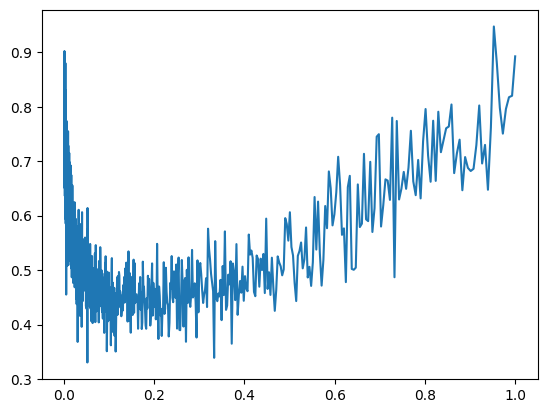

In [36]:
plt.plot(lri,lossi)